# Serial Repetition Lag-CRP

> Analyze repetition contiguity conditioned on correctly ordered recall.

The serial repetition CRP conditions on correctly ordered output up to the point of analysis. It tabulates repetition-index CRPs only for transitions where the recall sequence matches study order, stopping once an out-of-order response occurs. This isolates temporal contiguity effects in participants who are maintaining serial order.

## Workflow

In [1]:
import os

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.serialrepcrp import plot_rep_crp, subject_serial_rep_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

In [2]:
allow_repeated_recalls = True
filter_repeated_recalls = False
data_path = "../datasets/prepared/BroitmanKahana2024.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = [0, .4]
base_data_name = "BroitmanKahana2024"
trial_query = "data['listLength'] > 0"
min_lag = 2
max_lag = 3
size = 2

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

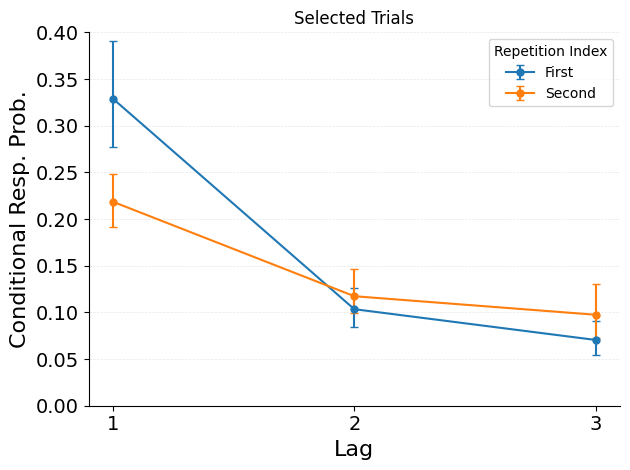

In [4]:
plot_rep_crp(
    datasets=data,
    trial_masks=trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
plt.title("Selected Trials")
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

Plots show repetition CRP curves computed only from correctly ordered recall prefixes. Key patterns:

- **Stronger contiguity under order**: if serial-order maintenance amplifies temporal contiguity, curves will be steeper than unconditioned repetition CRP.
- **First vs. second presentation**: reveals which occurrence drives transitions when participants recall in order.

## API Details

### Notebook parameters

This template uses the same parameter set as the repetition Lag-CRP template. See that template's API Details for parameter descriptions. Additional parameters:

- `allow_repeated_recalls` — whether the analysis permits repeated recalls.
- `filter_repeated_recalls` — whether to filter out repeated recall events.